In [8]:
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
graph = nx.read_gexf(BASE_DIR / "data" / "processed" / "world_trade_network_petrol_2024.gexf")

### 1) The Algorithm of Louvain:

In [14]:
# 1.1) Calculate the communities detected by Louvain and print its length: 
coms_louvain = list(nx.community.louvain_communities(graph, seed=42, weight='weight'))
print(f'{len(coms_louvain)} Louvain communities detected')

6 Louvain communities detected


In [15]:
# 1.2) Calculate the modularity of this partition (to see how decent it is): 
modularity = nx.community.modularity(graph, coms_louvain, weight='weight')
print(f'Modularity = {modularity}') # Decent modularity (bigger than 0.3).

Modularity = 0.39435707534547576


/tmp/ipykernel_6195/3061483296.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pallette = plt.cm.get_cmap('tab20', max(dict_louvain.values()) + 1)


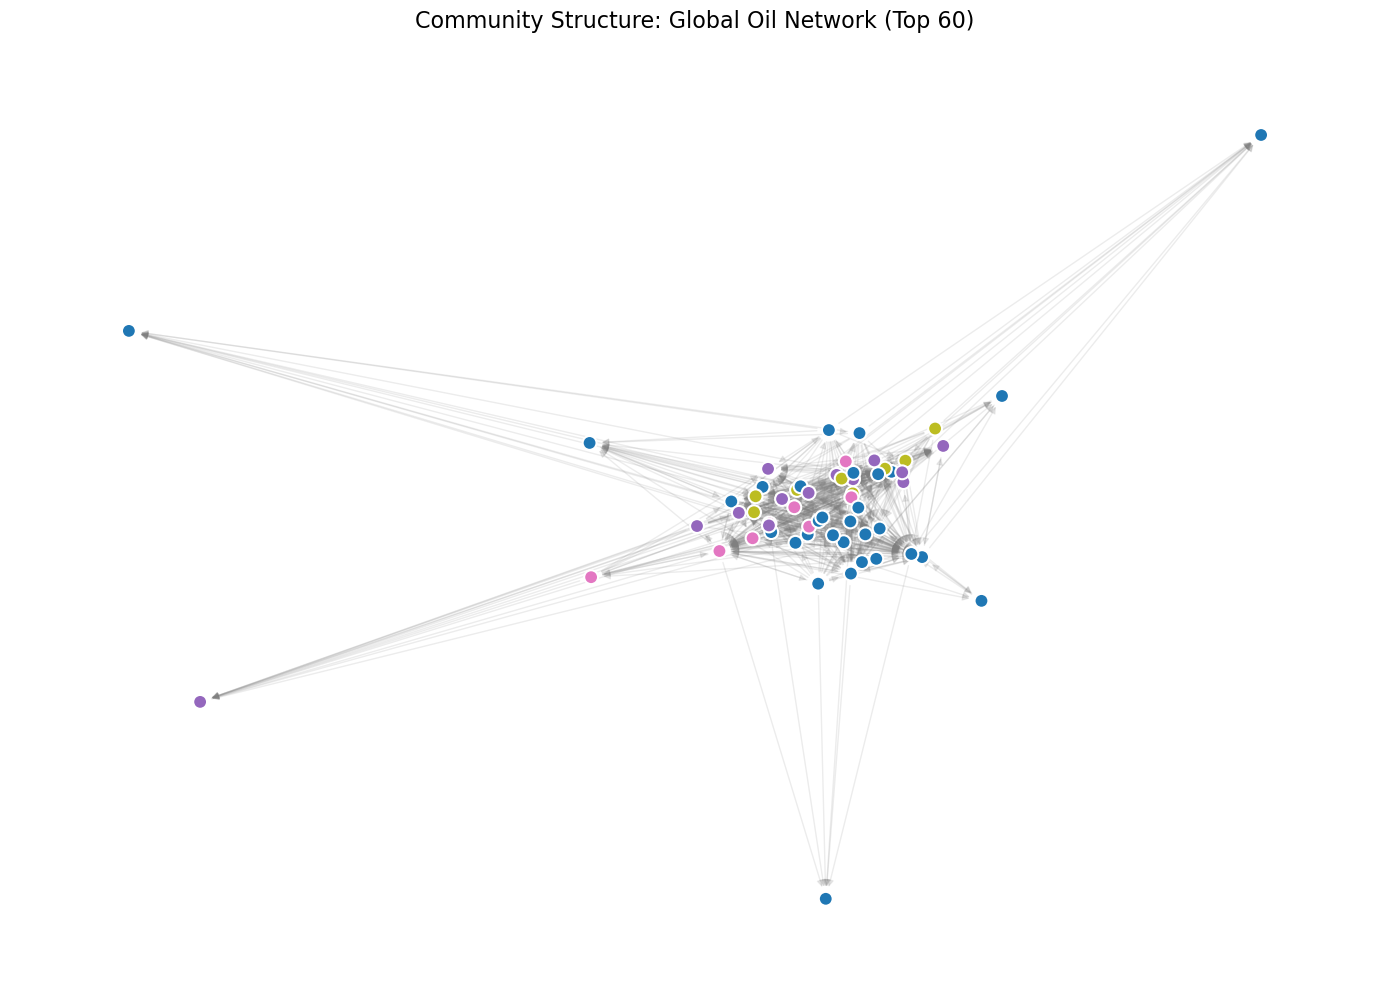

In [38]:
# 1.3) Visualize the graph with its calculated communities: 

# Filter the number of nodes in order to prevent saturation in the visualization: 
num_nodes = 60

degrees = dict(graph.degree(weight='weight'))
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:num_nodes]
filtered_graph = graph.subgraph(top_nodes)

# Create the respective dictionary for the communities calculated:
dict_louvain = {}
for i, com in enumerate(coms_louvain):
    for nodo in com:
        dict_louvain[nodo] = i

# Set colors for visualization: 
pallette = plt.cm.get_cmap('tab20', max(dict_louvain.values()) + 1)
node_colors = [pallette(dict_louvain[node]) for node in filtered_graph.nodes()]

# Adjust the sizes of nodes in terms of its degrees: 
parameter_size = 500000
node_sizes = [degrees[node] / parameter_size for node in filtered_graph.nodes()]

# Set the position on nodes using "spring_layout":
pos = nx.spring_layout(filtered_graph, weight='weight', seed=42, k=5, iterations=100)

# Paint the graph: 
num_labels = 0

plt.figure(figsize=(14, 10))
plt.title("Community Structure: Global Oil Network (Top 60)", fontsize=16, pad=20)

nx.draw_networkx_edges(filtered_graph, pos, alpha=0.15, edge_color='gray', arrows=True)
nx.draw_networkx_nodes(filtered_graph, pos, node_color=node_colors, 
                       node_size=100, edgecolors='white', linewidths=1.5)

top_labels = {n: n for n in sorted(top_nodes, key=degrees.get, reverse=True)[:num_labels]}
nx.draw_networkx_labels(filtered_graph, pos, labels=top_labels, font_size=10, font_weight='bold')

plt.axis('off')
plt.tight_layout()
plt.show()

### 2) Algorithom of Girvan-Newman: 